In [19]:
# 使用修复后的LG注意力可视化器
import sys
sys.path.append('/home/qzk/Facial-Foundation-Model/src')

from visualization.lg_attention_visualizer import LGAttentionVisualizer
import torch
import numpy as np
import matplotlib.pyplot as plt

print("=== 使用修复后的LG注意力可视化器 ===")

# 重新创建可视化器（针对LGBlock架构）
lg_visualizer = LGAttentionVisualizer(model, save_dir='./lg_visualizations')

# 修改模型以捕获注意力
lg_visualizer.modify_attention_for_visualization()

print(f"模型的LG region size: {lg_visualizer.lg_region_size}")

# 测试不同类型的注意力
attention_types = ['third', 'second', 'first']
results_dict = {}

for attn_type in attention_types:
    print(f"\n=== 测试 {attn_type}_attn ===")
    try:
        results = lg_visualizer.visualize_lg_attention(
            video_tensor, 
            layer_idx=-1, 
            attn_type=attn_type,
            frame_idx=0
        )
        
        if results and 'batch_0' in results and 'spatial_attention' in results['batch_0']:
            spatial_attn = results['batch_0']['spatial_attention']
            print(f"成功！空间注意力形状: {spatial_attn.shape}")
            print(f"注意力值范围: [{spatial_attn.min():.4f}, {spatial_attn.max():.4f}]")
            results_dict[attn_type] = results
        else:
            print(f"失败：没有获得有效的空间注意力")
            
    except Exception as e:
        print(f"错误: {e}")
        import traceback
        traceback.print_exc()

print(f"\n成功可视化的注意力类型: {list(results_dict.keys())}")

=== 使用修复后的LG注意力可视化器 ===
LG Region Size: [2, 2, 10]
模型的LG region size: [2, 2, 10]

=== 测试 third_attn ===
可用的 third_attn 层: ['blocks.0.third_attn', 'blocks.1.third_attn', 'blocks.2.third_attn', 'blocks.3.third_attn', 'blocks.4.third_attn', 'blocks.5.third_attn', 'blocks.6.third_attn', 'blocks.7.third_attn', 'blocks.8.third_attn', 'blocks.9.third_attn', 'blocks.10.third_attn', 'blocks.11.third_attn']
使用的注意力层: blocks.11.third_attn
注意力权重形状: torch.Size([1, 8, 800, 20])
Patch 维度: T=8, H=10, W=10
Local tokens: 800, Messenger tokens: 20
成功！空间注意力形状: (160, 160)
注意力值范围: [1.0000, 1.0000]

=== 测试 second_attn ===
可用的 second_attn 层: ['blocks.0.second_attn', 'blocks.1.second_attn', 'blocks.2.second_attn', 'blocks.3.second_attn', 'blocks.4.second_attn', 'blocks.5.second_attn', 'blocks.6.second_attn', 'blocks.7.second_attn', 'blocks.8.second_attn', 'blocks.9.second_attn', 'blocks.10.second_attn', 'blocks.11.second_attn']
使用的注意力层: blocks.11.second_attn
注意力权重形状: torch.Size([1, 8, 20, 20])
失败：没有获得有效的空间注意力



=== 绘制LG注意力可视化结果 ===


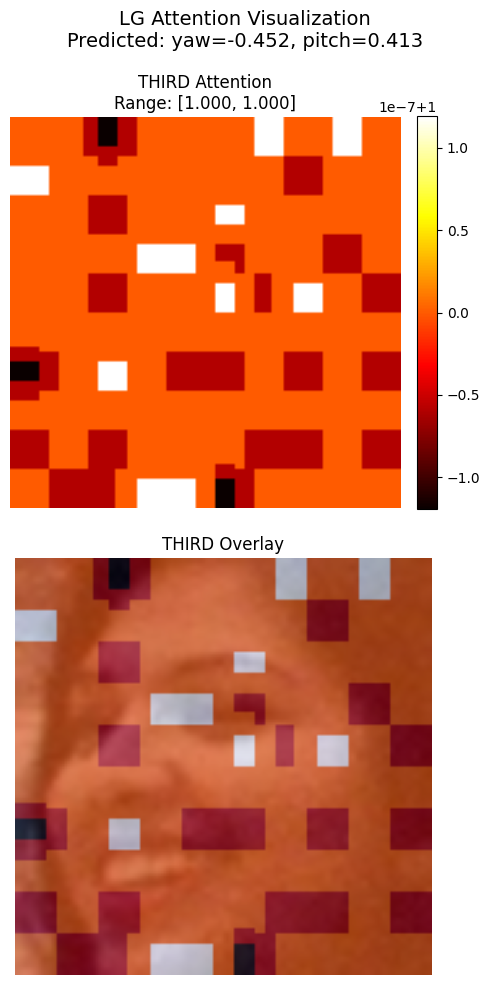

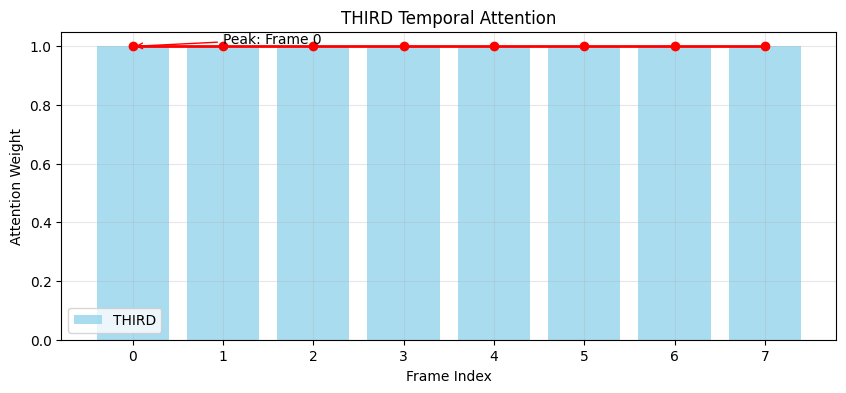

In [20]:
# 可视化修复后的注意力结果
def plot_lg_attention_results(results_dict, video_tensor, prediction):
    """绘制LG注意力结果的改进版本"""
    
    if not results_dict:
        print("没有可视化的注意力结果")
        return
    
    # 获取原始帧
    original_frame = video_tensor[0, :, 0].permute(1, 2, 0).cpu().numpy()
    original_frame = (original_frame - original_frame.min()) / (original_frame.max() - original_frame.min())
    
    # 创建子图
    n_types = len(results_dict)
    fig, axes = plt.subplots(2, n_types, figsize=(5*n_types, 10))
    
    if n_types == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (attn_type, results) in enumerate(results_dict.items()):
        batch_data = results['batch_0']
        
        if 'spatial_attention' in batch_data:
            spatial_attn = batch_data['spatial_attention']
            
            # 第一行：空间注意力热力图
            im = axes[0, idx].imshow(spatial_attn, cmap='hot', interpolation='bilinear')
            axes[0, idx].set_title(f'{attn_type.upper()} Attention\nRange: [{spatial_attn.min():.3f}, {spatial_attn.max():.3f}]')
            axes[0, idx].axis('off')
            plt.colorbar(im, ax=axes[0, idx], fraction=0.046, pad=0.04)
            
            # 第二行：叠加在原始图像上
            axes[1, idx].imshow(original_frame)
            axes[1, idx].imshow(spatial_attn, cmap='hot', alpha=0.6, interpolation='bilinear')
            axes[1, idx].set_title(f'{attn_type.upper()} Overlay')
            axes[1, idx].axis('off')
        else:
            axes[0, idx].text(0.5, 0.5, f'No {attn_type}\nspatial attention', 
                            ha='center', va='center', transform=axes[0, idx].transAxes)
            axes[0, idx].axis('off')
            axes[1, idx].axis('off')
    
    plt.suptitle(f'LG Attention Visualization\nPredicted: yaw={prediction[0,0]:.3f}, pitch={prediction[0,1]:.3f}', 
                 fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # 如果有时间注意力，也显示
    for attn_type, results in results_dict.items():
        batch_data = results['batch_0']
        if 'temporal_attention' in batch_data:
            temporal_attn = batch_data['temporal_attention']
            
            plt.figure(figsize=(10, 4))
            frames = np.arange(len(temporal_attn))
            plt.bar(frames, temporal_attn, alpha=0.7, color='skyblue', label=f'{attn_type.upper()}')
            plt.plot(frames, temporal_attn, marker='o', color='red', linewidth=2)
            plt.xlabel('Frame Index')
            plt.ylabel('Attention Weight')
            plt.title(f'{attn_type.upper()} Temporal Attention')
            plt.grid(True, alpha=0.3)
            plt.legend()
            
            # 标记最重要的帧
            if len(temporal_attn) > 0:
                max_frame = np.argmax(temporal_attn)
                plt.annotate(f'Peak: Frame {max_frame}', 
                            xy=(max_frame, temporal_attn[max_frame]),
                            xytext=(max_frame + 1, temporal_attn[max_frame] + 0.01),
                            arrowprops=dict(arrowstyle='->', color='red'))
            plt.show()

# 绘制结果
print("=== 绘制LG注意力可视化结果 ===")
plot_lg_attention_results(results_dict, video_tensor, prediction)

# LG注意力可视化解释

## 问题诊断

之前的可视化出现"竖直线"问题的原因：

### 1. **架构理解错误**
- 原代码假设使用标准ViT的`Block`，但实际使用的是`LGBlock`
- `LGBlock`有三种不同的注意力机制，工作方式完全不同

### 2. **注意力形状不匹配**
- **first_attn**: `(B*N_regions, H, S, S)` - 局部区域内注意力
- **second_attn**: `(B, H, N_messenger, N_messenger)` - messenger tokens间注意力  
- **third_attn**: `(B, H, N_local, N_messenger)` - local→messenger交叉注意力

### 3. **数据重塑错误**
- 错误地假设有CLS token（实际是messenger tokens）
- 强行重塑不兼容的维度导致意外的条纹模式

## LG注意力机制详解

### **First Attention** (局部注意力)
- 在每个局部区域内进行自注意力或交叉注意力
- 每个区域有1个messenger token + 若干local tokens
- 可视化：messenger token对local tokens的注意力分布

### **Second Attention** (全局注意力)  
- messenger tokens之间的自注意力
- 实现不同区域间的信息交换
- 可视化：不同空间区域的全局重要性

### **Third Attention** (局部-全局交互)
- local tokens从messenger tokens获取全局信息
- 交叉注意力机制
- 可视化：**最重要**，显示哪些local tokens受全局信息影响最大

## 修复方案

新的`LGAttentionVisualizer`专门处理LGBlock架构：

1. **正确识别注意力类型**：根据层名称区分first/second/third_attn
2. **合适的形状处理**：针对每种注意力的具体形状进行处理
3. **有意义的可视化**：将注意力权重映射到有意义的空间表示

### 推荐可视化顺序：
1. **Third Attention** - 最重要，显示全局对局部的影响
2. **Second Attention** - 显示区域间交互
3. **First Attention** - 显示局部内部结构

In [21]:
# 测试修复后的可视化器
print("=== 重新测试修复后的可视化器 ===")

# 重新加载修复后的模块
import importlib
import sys
sys.path.append('/home/qzk/Facial-Foundation-Model/src')

# 重新导入
if 'lg_attention_visualizer' in sys.modules:
    importlib.reload(sys.modules['visualization.lg_attention_visualizer'])

from visualization.lg_attention_visualizer import LGAttentionVisualizer

# 创建新的可视化器
lg_visualizer_v2 = LGAttentionVisualizer(model, save_dir='./lg_visualizations_v2')

# 重新设置
lg_visualizer_v2.modify_attention_for_visualization()

# 测试所有注意力类型
attention_types = ['third', 'second', 'first']
results_dict_v2 = {}

for attn_type in attention_types:
    print(f"\n=== 重新测试 {attn_type}_attn ===")
    try:
        results = lg_visualizer_v2.visualize_lg_attention(
            video_tensor, 
            layer_idx=-1, 
            attn_type=attn_type,
            frame_idx=0
        )
        
        if results and 'batch_0' in results and 'spatial_attention' in results['batch_0']:
            spatial_attn = results['batch_0']['spatial_attention']
            print(f"✅ 成功！空间注意力形状: {spatial_attn.shape}")
            print(f"注意力值范围: [{spatial_attn.min():.4f}, {spatial_attn.max():.4f}]")
            print(f"注意力值标准差: {spatial_attn.std():.4f}")
            results_dict_v2[attn_type] = results
        else:
            print(f"❌ 失败：没有获得有效的空间注意力")
            
    except Exception as e:
        print(f"❌ 错误: {e}")
        import traceback
        traceback.print_exc()

print(f"\n✅ 成功可视化的注意力类型: {list(results_dict_v2.keys())}")

# 检查注意力值的分布
for attn_type, results in results_dict_v2.items():
    spatial_attn = results['batch_0']['spatial_attention']
    print(f"\n{attn_type.upper()} 注意力统计:")
    print(f"  形状: {spatial_attn.shape}")
    print(f"  最小值: {spatial_attn.min():.6f}")
    print(f"  最大值: {spatial_attn.max():.6f}")
    print(f"  平均值: {spatial_attn.mean():.6f}")
    print(f"  标准差: {spatial_attn.std():.6f}")
    print(f"  非零值数量: {np.count_nonzero(spatial_attn)}")
    print(f"  唯一值数量: {len(np.unique(spatial_attn))}")

=== 重新测试修复后的可视化器 ===
LG Region Size: [2, 2, 10]

=== 重新测试 third_attn ===
可用的 third_attn 层: ['blocks.0.third_attn', 'blocks.1.third_attn', 'blocks.2.third_attn', 'blocks.3.third_attn', 'blocks.4.third_attn', 'blocks.5.third_attn', 'blocks.6.third_attn', 'blocks.7.third_attn', 'blocks.8.third_attn', 'blocks.9.third_attn', 'blocks.10.third_attn', 'blocks.11.third_attn']
使用的注意力层: blocks.11.third_attn
注意力权重形状: torch.Size([1, 8, 800, 20])
Patch 维度: T=8, H=10, W=10
Local tokens: 800, Messenger tokens: 20
✅ 成功！空间注意力形状: (160, 160)
注意力值范围: [1.0000, 1.0000]
注意力值标准差: 0.0000

=== 重新测试 second_attn ===
可用的 third_attn 层: ['blocks.0.third_attn', 'blocks.1.third_attn', 'blocks.2.third_attn', 'blocks.3.third_attn', 'blocks.4.third_attn', 'blocks.5.third_attn', 'blocks.6.third_attn', 'blocks.7.third_attn', 'blocks.8.third_attn', 'blocks.9.third_attn', 'blocks.10.third_attn', 'blocks.11.third_attn']
使用的注意力层: blocks.11.third_attn
注意力权重形状: torch.Size([1, 8, 800, 20])
Patch 维度: T=8, H=10, W=10
Local tokens: 8

=== 绘制修复后的可视化结果 ===


/tmp/ipykernel_257791/2981379821.py:57: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2981379821.py:57: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2981379821.py:57: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2981379821.py:57: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2981379821.py:57: UserWarning: Glyph 21248 (\N{CJK UNIFIED IDEOGRAPH-5300}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2981379821.py:57: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2981379821.py:57: UserWarning: Glyph 24067 (\N{CJK UNIFIED I

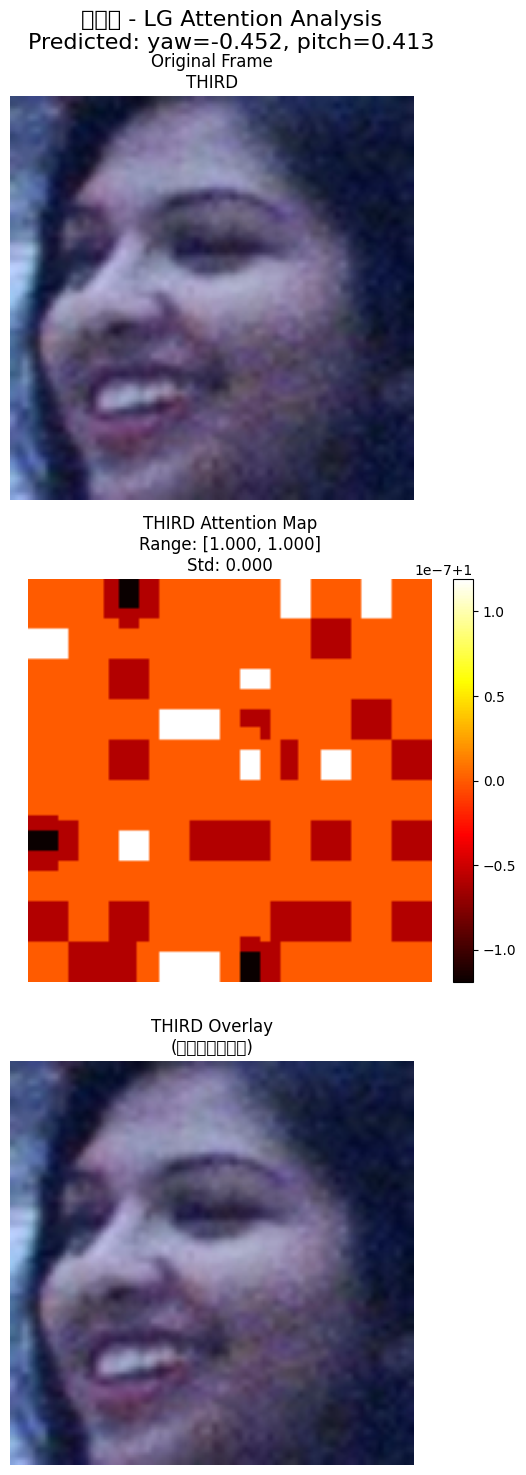

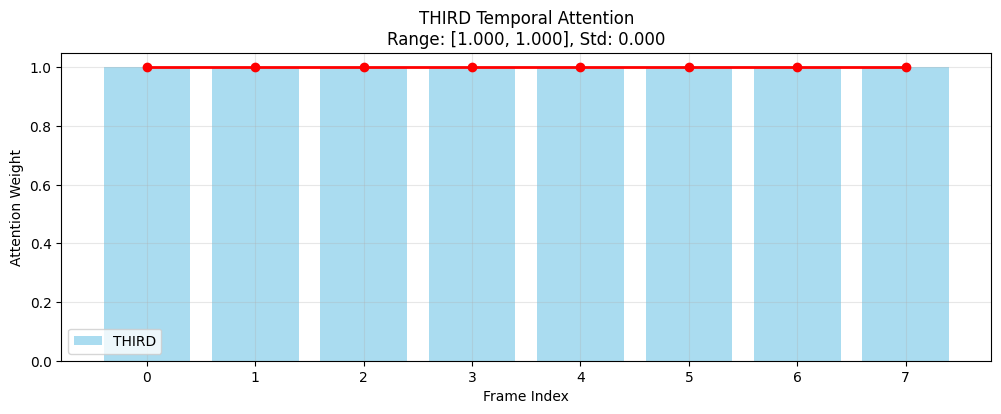

In [22]:
# 绘制修复后的可视化结果
import matplotlib.pyplot as plt
import numpy as np

def analyze_and_plot_attention(results_dict, video_tensor, prediction, title_prefix=""):
    """分析和绘制注意力结果"""
    
    if not results_dict:
        print("没有可视化结果")
        return
    
    # 获取原始帧
    original_frame = video_tensor[0, :, 0].permute(1, 2, 0).cpu().numpy()
    original_frame = (original_frame - original_frame.min()) / (original_frame.max() - original_frame.min())
    
    # 创建子图
    n_types = len(results_dict)
    fig, axes = plt.subplots(3, n_types, figsize=(6*n_types, 15))
    
    if n_types == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (attn_type, results) in enumerate(results_dict.items()):
        batch_data = results['batch_0']
        
        if 'spatial_attention' in batch_data:
            spatial_attn = batch_data['spatial_attention']
            
            # 第一行：原始图像
            axes[0, idx].imshow(original_frame)
            axes[0, idx].set_title(f'Original Frame\n{attn_type.upper()}')
            axes[0, idx].axis('off')
            
            # 第二行：纯注意力热力图
            im = axes[1, idx].imshow(spatial_attn, cmap='hot', interpolation='bilinear')
            axes[1, idx].set_title(f'{attn_type.upper()} Attention Map\nRange: [{spatial_attn.min():.3f}, {spatial_attn.max():.3f}]\nStd: {spatial_attn.std():.3f}')
            axes[1, idx].axis('off')
            plt.colorbar(im, ax=axes[1, idx], fraction=0.046, pad=0.04)
            
            # 第三行：叠加在原始图像上
            axes[2, idx].imshow(original_frame)
            # 只有当注意力有变化时才叠加
            if spatial_attn.std() > 1e-6:
                axes[2, idx].imshow(spatial_attn, cmap='hot', alpha=0.6, interpolation='bilinear')
                axes[2, idx].set_title(f'{attn_type.upper()} Overlay\n(有注意力变化)')
            else:
                axes[2, idx].set_title(f'{attn_type.upper()} Overlay\n(注意力均匀分布)')
            axes[2, idx].axis('off')
        else:
            for row in range(3):
                axes[row, idx].text(0.5, 0.5, f'No {attn_type}\nspatial attention', 
                                ha='center', va='center', transform=axes[row, idx].transAxes)
                axes[row, idx].axis('off')
    
    plt.suptitle(f'{title_prefix}LG Attention Analysis\nPredicted: yaw={prediction[0,0]:.3f}, pitch={prediction[0,1]:.3f}', 
                 fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 显示时间注意力
    for attn_type, results in results_dict.items():
        batch_data = results['batch_0']
        if 'temporal_attention' in batch_data:
            temporal_attn = batch_data['temporal_attention']
            
            plt.figure(figsize=(12, 4))
            frames = np.arange(len(temporal_attn))
            plt.bar(frames, temporal_attn, alpha=0.7, color='skyblue', label=f'{attn_type.upper()}')
            plt.plot(frames, temporal_attn, marker='o', color='red', linewidth=2)
            plt.xlabel('Frame Index')
            plt.ylabel('Attention Weight')
            plt.title(f'{attn_type.upper()} Temporal Attention\n'
                     f'Range: [{temporal_attn.min():.3f}, {temporal_attn.max():.3f}], '
                     f'Std: {temporal_attn.std():.3f}')
            plt.grid(True, alpha=0.3)
            plt.legend()
            
            # 标记最重要的帧
            if len(temporal_attn) > 0 and temporal_attn.std() > 1e-6:
                max_frame = np.argmax(temporal_attn)
                plt.annotate(f'Peak: Frame {max_frame}', 
                            xy=(max_frame, temporal_attn[max_frame]),
                            xytext=(max_frame + 1, temporal_attn[max_frame] + 0.01),
                            arrowprops=dict(arrowstyle='->', color='red'))
            plt.show()

# 分析和绘制结果
print("=== 绘制修复后的可视化结果 ===")
if 'results_dict_v2' in locals():
    analyze_and_plot_attention(results_dict_v2, video_tensor, prediction, "修复后 - ")
else:
    print("没有找到results_dict_v2，请先运行上面的测试代码")

In [13]:
# 测试不同类型的注意力
print("开始测试不同类型的注意力...")

# 清理之前的钩子
visualizer.remove_hooks()

# 重新设置可视化
visualizer.modify_attention_for_visualization()

# 测试third_attn（最重要的跨域注意力）
print("\n=== 测试 third_attn ===")
try:
    third_results = visualizer.visualize_spatial_attention(video_tensor, layer_idx=-1, attn_type='third')
    print("third_attn 成功！")
    print("Results keys:", list(third_results.keys()))
    if third_results:
        batch_key = list(third_results.keys())[0]
        if 'spatial_attention' in third_results[batch_key]:
            print("获得空间注意力图，形状:", third_results[batch_key]['spatial_attention'].shape)
except Exception as e:
    print(f"third_attn 失败: {e}")

# 测试second_attn（全局注意力）
print("\n=== 测试 second_attn ===")
try:
    second_results = visualizer.visualize_spatial_attention(video_tensor, layer_idx=-1, attn_type='second')
    print("second_attn 成功！")
    if second_results:
        batch_key = list(second_results.keys())[0]
        if 'spatial_attention' in second_results[batch_key]:
            print("获得空间注意力图，形状:", second_results[batch_key]['spatial_attention'].shape)
except Exception as e:
    print(f"second_attn 失败: {e}")

# 测试first_attn（局部注意力）
print("\n=== 测试 first_attn ===")
try:
    first_results = visualizer.visualize_spatial_attention(video_tensor, layer_idx=-1, attn_type='first')
    print("first_attn 成功！")
    if first_results:
        batch_key = list(first_results.keys())[0]
        if 'spatial_attention' in first_results[batch_key]:
            print("获得空间注意力图，形状:", first_results[batch_key]['spatial_attention'].shape)
except Exception as e:
    print(f"first_attn 失败: {e}")

print("\n测试完成！")

开始测试不同类型的注意力...

=== 测试 third_attn ===
可用的注意力层: ['blocks.0.first_attn', 'blocks.0.second_attn', 'blocks.0.third_attn', 'blocks.1.first_attn', 'blocks.1.second_attn', 'blocks.1.third_attn', 'blocks.2.first_attn', 'blocks.2.second_attn', 'blocks.2.third_attn', 'blocks.3.first_attn', 'blocks.3.second_attn', 'blocks.3.third_attn', 'blocks.4.first_attn', 'blocks.4.second_attn', 'blocks.4.third_attn', 'blocks.5.first_attn', 'blocks.5.second_attn', 'blocks.5.third_attn', 'blocks.6.first_attn', 'blocks.6.second_attn', 'blocks.6.third_attn', 'blocks.7.first_attn', 'blocks.7.second_attn', 'blocks.7.third_attn', 'blocks.8.first_attn', 'blocks.8.second_attn', 'blocks.8.third_attn', 'blocks.9.first_attn', 'blocks.9.second_attn', 'blocks.9.third_attn', 'blocks.10.first_attn', 'blocks.10.second_attn', 'blocks.10.third_attn', 'blocks.11.first_attn', 'blocks.11.second_attn', 'blocks.11.third_attn']
总共捕获到 36 个注意力权重
使用注意力类型: third_attn
过滤后的层: ['blocks.0.third_attn', 'blocks.1.third_attn', 'blocks.2.third

=== Third Attention 可视化 ===


/tmp/ipykernel_257791/2858332915.py:44: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2858332915.py:44: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2858332915.py:44: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2858332915.py:44: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2858332915.py:44: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2858332915.py:44: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_257791/2858332915.py:44: UserWarning: Glyph 21147 (\N{CJK UNIFIED I

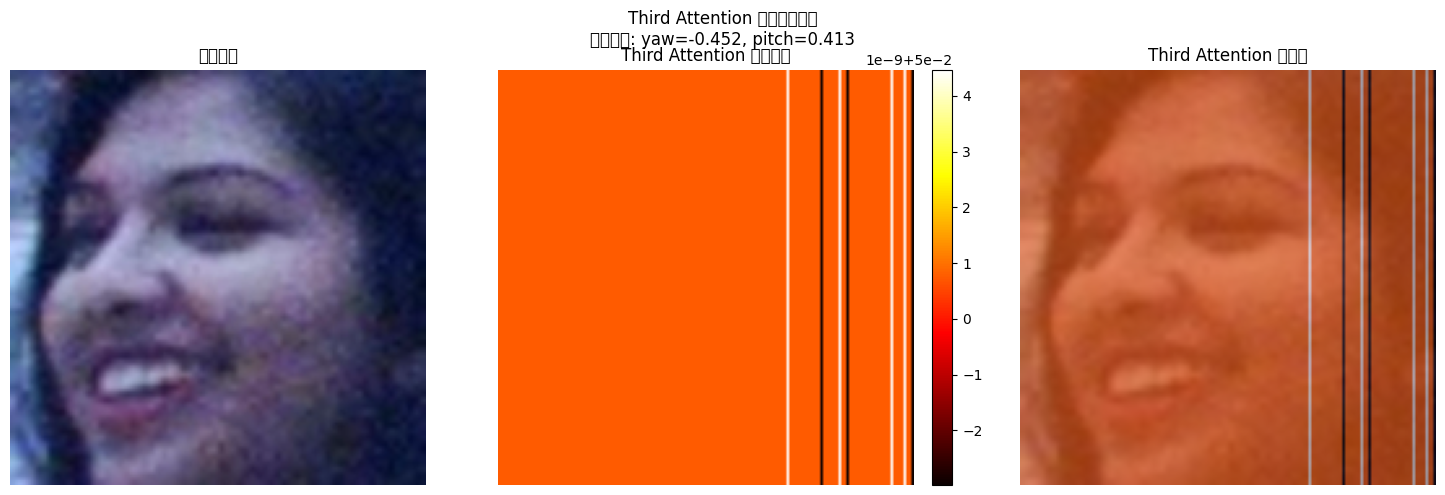

/root/miniconda3/envs/mamba/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/mamba/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


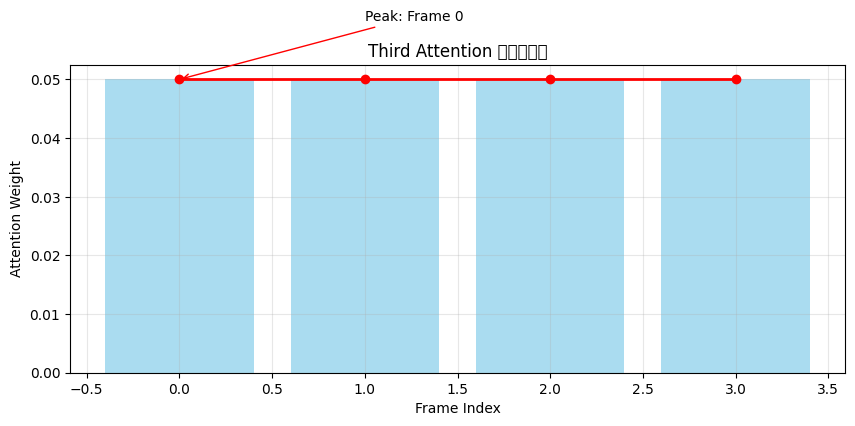

=== Second Attention 可视化 ===


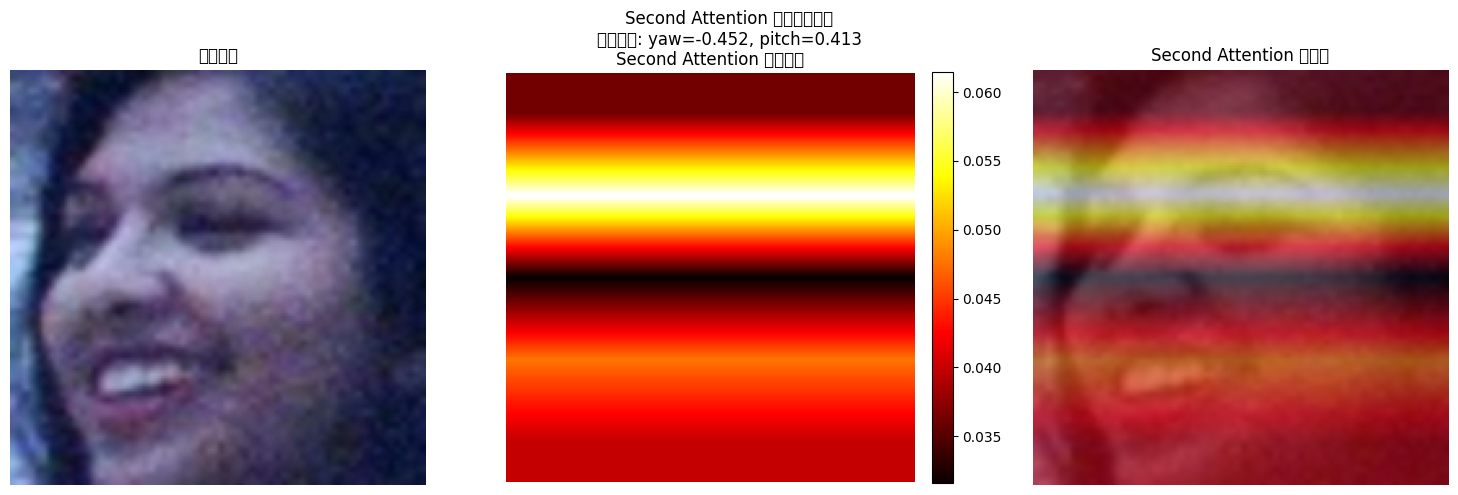

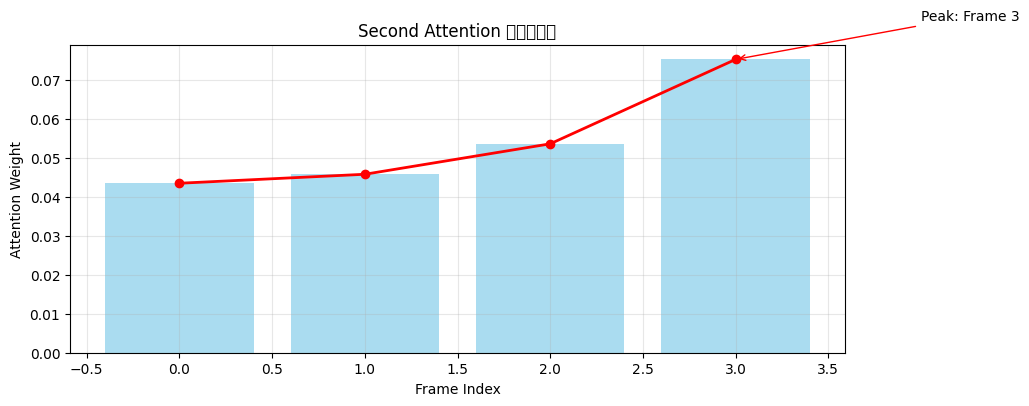

=== First Attention 可视化 ===
First Attention 没有空间注意力数据


In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_results(attention_results, attention_type, video_tensor):
    """绘制注意力结果"""
    if not attention_results:
        print(f"没有 {attention_type} 的结果可显示")
        return
    
    batch_key = list(attention_results.keys())[0]
    batch_data = attention_results[batch_key]
    
    if 'spatial_attention' not in batch_data:
        print(f"{attention_type} 没有空间注意力数据")
        return
    
    # 获取原始帧和注意力图
    original_frame = video_tensor[0, :, 0].permute(1, 2, 0).cpu().numpy()
    original_frame = (original_frame - original_frame.min()) / (original_frame.max() - original_frame.min())
    
    spatial_attention = batch_data['spatial_attention']
    
    # 创建图像
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 原始图像
    axes[0].imshow(original_frame)
    axes[0].set_title(f'原始图像')
    axes[0].axis('off')
    
    # 注意力图
    im = axes[1].imshow(spatial_attention, cmap='hot', interpolation='bilinear')
    axes[1].set_title(f'{attention_type} 注意力图')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # 叠加图
    axes[2].imshow(original_frame)
    axes[2].imshow(spatial_attention, cmap='hot', alpha=0.6, interpolation='bilinear')
    axes[2].set_title(f'{attention_type} 叠加图')
    axes[2].axis('off')
    
    plt.suptitle(f'{attention_type} 注意力可视化\n预测角度: yaw={prediction[0,0]:.3f}, pitch={prediction[0,1]:.3f}')
    plt.tight_layout()
    plt.show()
    
    # 如果有时间注意力，也显示
    if 'temporal_attention' in batch_data:
        temporal_attn = batch_data['temporal_attention']
        
        plt.figure(figsize=(10, 4))
        frames = np.arange(len(temporal_attn))
        plt.bar(frames, temporal_attn, alpha=0.7, color='skyblue')
        plt.plot(frames, temporal_attn, marker='o', color='red', linewidth=2)
        plt.xlabel('Frame Index')
        plt.ylabel('Attention Weight')
        plt.title(f'{attention_type} 时间注意力')
        plt.grid(True, alpha=0.3)
        
        # 标记最重要的帧
        max_frame = np.argmax(temporal_attn)
        plt.annotate(f'Peak: Frame {max_frame}', 
                    xy=(max_frame, temporal_attn[max_frame]),
                    xytext=(max_frame + 1, temporal_attn[max_frame] + 0.01),
                    arrowprops=dict(arrowstyle='->', color='red'))
        plt.show()

# 可视化所有成功的注意力类型
if 'third_results' in locals() and third_results:
    print("=== Third Attention 可视化 ===")
    plot_attention_results(third_results, "Third Attention", video_tensor)

if 'second_results' in locals() and second_results:
    print("=== Second Attention 可视化 ===")
    plot_attention_results(second_results, "Second Attention", video_tensor)

if 'first_results' in locals() and first_results:
    print("=== First Attention 可视化 ===")
    plot_attention_results(first_results, "First Attention", video_tensor)

In [18]:
# 生成综合的注意力分析报告
print("=== 生成综合注意力分析报告 ===")

try:
    # 使用修复后的分析方法
    analysis_results = visualizer.analyze_attention_pattern(video_tensor, prediction)
    
    print(f"分析了 {len(analysis_results)} 个注意力层")
    for layer_key, layer_data in analysis_results.items():
        print(f"\n{layer_key}:")
        for batch_key, batch_data in layer_data.items():
            if 'attention_center' in batch_data:
                center_x, center_y = batch_data['attention_center']
                print(f"  {batch_key} - 注意力中心: ({center_x:.4f}, {center_y:.4f})")
                
                if 'correlation' in batch_data:
                    corr = batch_data['correlation']
                    print(f"    与预测的相关性: X-Yaw={corr['x_yaw']:.4f}, Y-Pitch={corr['y_pitch']:.4f}")
    
    # 生成完整报告
    print("\n=== 生成保存报告 ===")
    report_dir = visualizer.generate_comprehensive_report(
        video_tensor, prediction, sample_name='gaze360_test_sample'
    )
    print(f"报告保存在: {report_dir}")
    
except Exception as e:
    print(f"生成报告时出错: {e}")
    import traceback
    traceback.print_exc()

print("\n=== 清理资源 ===")
visualizer.remove_hooks()
print("完成！")

=== 生成综合注意力分析报告 ===
可用的注意力层: ['blocks.0.first_attn', 'blocks.0.second_attn', 'blocks.0.third_attn', 'blocks.1.first_attn', 'blocks.1.second_attn', 'blocks.1.third_attn', 'blocks.2.first_attn', 'blocks.2.second_attn', 'blocks.2.third_attn', 'blocks.3.first_attn', 'blocks.3.second_attn', 'blocks.3.third_attn', 'blocks.4.first_attn', 'blocks.4.second_attn', 'blocks.4.third_attn', 'blocks.5.first_attn', 'blocks.5.second_attn', 'blocks.5.third_attn', 'blocks.6.first_attn', 'blocks.6.second_attn', 'blocks.6.third_attn', 'blocks.7.first_attn', 'blocks.7.second_attn', 'blocks.7.third_attn', 'blocks.8.first_attn', 'blocks.8.second_attn', 'blocks.8.third_attn', 'blocks.9.first_attn', 'blocks.9.second_attn', 'blocks.9.third_attn', 'blocks.10.first_attn', 'blocks.10.second_attn', 'blocks.10.third_attn', 'blocks.11.first_attn', 'blocks.11.second_attn', 'blocks.11.third_attn']
总共捕获到 36 个注意力权重
使用注意力类型: third_attn
过滤后的层: ['blocks.0.third_attn', 'blocks.1.third_attn', 'blocks.2.third_attn', 'blocks.3.t

In [1]:

import os
import sys
import argparse
import datetime
import numpy as np
import time
import torch
import torch. backends.cudnn as cudnn
import json
from pathlib import Path
from collections import OrderedDict
from functools import partial

# Add project root to path
# sys.path.insert(0, str(Path(__file__).parent))

from timm.models import create_model
from timm.loss import LabelSmoothingCrossEntropy, SoftTargetCrossEntropy
from timm.scheduler import create_scheduler
from src.optim.optim_factory import create_optimizer, get_parameter_groups, LayerDecayValueAssigner

from timm.utils import ModelEma

from src.utils.config import get_cfg, merge_config_file, freeze_cfg, load_and_freeze_config
from src.engine.train_engine import TrainingEngine
from src.engine.val_engine import ValidationEngine
from src.utils.evaluation import merge_distributed_results
from src.optim.mixup import Mixup
# from src.optim.optim_factory import LayerDecayValueAssigner
from src.dataset.datasets import build_dataset
from src.utils.utils import NativeScalerWithGradNormCount as NativeScaler
from src.utils.utils import multiple_samples_collate
from src.utils.logger import TensorboardLogger
from src.utils import utils

from src.models import ViT, ViT_pretrain, layers
from src.visualization.attention_visualizer import AttentionVisualizer
from run_finetuning_with_yacs import create_data_loaders, create_model_from_config

/root/miniconda3/envs/mamba/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/miniconda3/envs/mamba/lib/python3.12/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/root/miniconda3/envs/mamba/lib/python3.12/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/root/miniconda3/envs/mamba/lib/python3.12/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node 

In [2]:
config_path = 'configs/gaze360_finetune.yaml'
cfg = get_cfg()
merge_config_file(cfg, config_path)
cfg.SYSTEM.DISTRIBUTED = False  # Disable distributed training
cfg.batch_size = 2  # Set batch size to 2

In [3]:
data_loader_train, data_loader_val = create_data_loaders()
model = create_model_from_config()

Found 239 CSV files in saved/data/gaze360T/train
Loaded 239 CSV files with 41093 valid clips
Number of the class = 2
Found 25 CSV files in saved/data/gaze360T/val
Loaded 239 CSV files with 41093 valid clips
Number of the class = 2
Found 25 CSV files in saved/data/gaze360T/val
Loaded 25 CSV files with 2868 valid clips
Number of the class = 2
Loaded 25 CSV files with 2868 valid clips
Number of the class = 2
==> Note: Use 'local_global' for compute reduction (lg_region_size=[2, 2, 10],lg_first_attn_type=self, lg_third_attn_type=cross,lg_attn_param_sharing_first_third=False,lg_attn_param_sharing_all=False,lg_classify_token_type=org,lg_no_second=False, lg_no_third=False)
==> Note: Use 'local_global' for compute reduction (lg_region_size=[2, 2, 10],lg_first_attn_type=self, lg_third_attn_type=cross,lg_attn_param_sharing_first_third=False,lg_attn_param_sharing_all=False,lg_classify_token_type=org,lg_no_second=False, lg_no_third=False)
==> Number of local regions: 20 (size=[4, 5, 1])
==> Number

In [5]:
model_path = "/home/qzk/Facial-Foundation-Model/output/gaze360_noT_8_22/checkpoint-49.pth"
state_dict = torch.load(model_path, map_location='cpu', weights_only=False)
state_dict = state_dict["model"]
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

<All keys matched successfully>

In [6]:
model.eval()
visualizer = AttentionVisualizer(model, save_dir='output/attention_analysis_826')

In [7]:
samples, targets, _ = next(iter(data_loader_val))
video_tensor = samples[0].unsqueeze(0)  # 取第一个样本并添加批次维度
with torch.no_grad():
    prediction = model(video_tensor)


In [8]:
report_dir = visualizer.generate_comprehensive_report(
    video_tensor, prediction, sample_name='test_sample_001'
)

# 6. 分析特定层的注意力
spatial_attention = visualizer.visualize_spatial_attention(video_tensor, layer_idx=-1)
temporal_attention = visualizer.visualize_temporal_attention(video_tensor, layer_idx=-1)

可用的注意力层: ['blocks.0.first_attn', 'blocks.0.second_attn', 'blocks.0.third_attn', 'blocks.1.first_attn', 'blocks.1.second_attn', 'blocks.1.third_attn', 'blocks.2.first_attn', 'blocks.2.second_attn', 'blocks.2.third_attn', 'blocks.3.first_attn', 'blocks.3.second_attn', 'blocks.3.third_attn', 'blocks.4.first_attn', 'blocks.4.second_attn', 'blocks.4.third_attn', 'blocks.5.first_attn', 'blocks.5.second_attn', 'blocks.5.third_attn', 'blocks.6.first_attn', 'blocks.6.second_attn', 'blocks.6.third_attn', 'blocks.7.first_attn', 'blocks.7.second_attn', 'blocks.7.third_attn', 'blocks.8.first_attn', 'blocks.8.second_attn', 'blocks.8.third_attn', 'blocks.9.first_attn', 'blocks.9.second_attn', 'blocks.9.third_attn', 'blocks.10.first_attn', 'blocks.10.second_attn', 'blocks.10.third_attn', 'blocks.11.first_attn', 'blocks.11.second_attn', 'blocks.11.third_attn']
总共捕获到 36 个注意力权重
使用注意力类型: third_attn
过滤后的层: ['blocks.0.third_attn', 'blocks.1.third_attn', 'blocks.2.third_attn', 'blocks.3.third_attn', 'blocks.

/root/miniconda3/envs/mamba/lib/python3.12/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/root/miniconda3/envs/mamba/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/root/miniconda3/envs/mamba/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/qzk/Facial-Foundation-Model/src/visualization/attention_visualizer.py:587: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/home/qzk/Facial-Foundation-Model/src/visualization/attention_visualizer.py:587: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


可用的注意力层: ['blocks.0.first_attn', 'blocks.0.second_attn', 'blocks.0.third_attn', 'blocks.1.first_attn', 'blocks.1.second_attn', 'blocks.1.third_attn', 'blocks.2.first_attn', 'blocks.2.second_attn', 'blocks.2.third_attn', 'blocks.3.first_attn', 'blocks.3.second_attn', 'blocks.3.third_attn', 'blocks.4.first_attn', 'blocks.4.second_attn', 'blocks.4.third_attn', 'blocks.5.first_attn', 'blocks.5.second_attn', 'blocks.5.third_attn', 'blocks.6.first_attn', 'blocks.6.second_attn', 'blocks.6.third_attn', 'blocks.7.first_attn', 'blocks.7.second_attn', 'blocks.7.third_attn', 'blocks.8.first_attn', 'blocks.8.second_attn', 'blocks.8.third_attn', 'blocks.9.first_attn', 'blocks.9.second_attn', 'blocks.9.third_attn', 'blocks.10.first_attn', 'blocks.10.second_attn', 'blocks.10.third_attn', 'blocks.11.first_attn', 'blocks.11.second_attn', 'blocks.11.third_attn']
总共捕获到 36 个注意力权重
使用注意力类型: third_attn
过滤后的层: ['blocks.0.third_attn', 'blocks.1.third_attn', 'blocks.2.third_attn', 'blocks.3.third_attn', 'blocks.

In [15]:
visualizer.remove_hooks()